# Part 1: Data Preprocessing & Feature Engineering 

## Data Download and Schema Overview

In [30]:
import polars as pl
import pathlib as pathlb
from sklearn.preprocessing import StandardScaler, OneHotEncoder

file_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
base_dir = pathlb.Path('data/raw')
file_name = 'yellow_tripdata_2024-01.parquet'
file_path = base_dir/file_name

## Checks if file downloaded if not it downloads it
if not file_path.is_file() :
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_parquet(file_url).write_parquet(file_path)
taxi_df = pl.read_parquet(file_path)

print(f"{"SCHEMA"}\n")
print(f"{"Name":<25}Type")
for col, type in taxi_df.schema.items() :
    print(f"{col:<25}{type}")


taxi_df.head()

SCHEMA

Name                     Type
VendorID                 Int32
tpep_pickup_datetime     Datetime(time_unit='ns', time_zone=None)
tpep_dropoff_datetime    Datetime(time_unit='ns', time_zone=None)
passenger_count          Int64
trip_distance            Float64
RatecodeID               Int64
store_and_fwd_flag       String
PULocationID             Int32
DOLocationID             Int32
payment_type             Int64
fare_amount              Float64
extra                    Float64
mta_tax                  Float64
tip_amount               Float64
tolls_amount             Float64
improvement_surcharge    Float64
total_amount             Float64
congestion_surcharge     Float64
Airport_fee              Float64


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0


In [31]:
cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime','trip_distance','PULocationID', 'DOLocationID','fare_amount','tip_amount','payment_type']

try:
    # taxi_df should already be defined as a Polars DataFrame
    missing_cols = set(cols) - set(taxi_df.columns)

    if missing_cols:
        print("Missing columns:", missing_cols)
    else:
        print("No missing columns.")
except Exception as e:
    print("Error while checking columns:", e)

No missing columns.


Injesting Lookup file

In [32]:
file_name ='lookup.csv'
file_path = base_dir / file_name
file_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'

if not file_path.is_file():
    base_dir.mkdir(parents=True, exist_ok=True)
    print(f" Error {file_name} not found downloading...\n")
    pl.read_csv(file_url,encoding="utf8-lossy").write_csv(file_path)

lookup_df = pl.read_csv(file_path)

## Data Cleaning


### Cleaning Taxi Parquet

In [ ]:
initial_rows = len(taxi_df)

# --- STEP 1: Nulls and NaNs ---
# We calculate null_rows by checking how many rows fail the 'is_not_null' check
null_rows = initial_rows - taxi_df.filter(pl.all_horizontal(pl.col(cols).is_not_null())).height

# Apply the filter for both Nulls and NaNs
taxi_df = taxi_df.filter(
    pl.all_horizontal(pl.col(cols).is_not_null()) &
    (~pl.col("fare_amount").is_nan()) & 
    (~pl.col("trip_distance").is_nan())
)
# nan_rows is what's left after accounting for nulls
nan_rows = initial_rows - len(taxi_df) - null_rows

# --- STEP 2: Distance ---
pre_dist_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('trip_distance') > 0)
distance_rows = pre_dist_count - len(taxi_df)

# --- STEP 3: Fare ---
pre_fare_count = len(taxi_df)
taxi_df = taxi_df.filter((pl.col('fare_amount') > 0) & (pl.col('fare_amount') <= 500))
fare_rows = pre_fare_count - len(taxi_df)

# --- STEP 4: Time Duration ---
pre_time_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('tpep_dropoff_datetime') > pl.col('tpep_pickup_datetime'))
time_rows = pre_time_count - len(taxi_df)

# --- STEP 5: Year/Date Range ---
pre_year_count = len(taxi_df)
taxi_df = taxi_df.filter(pl.col('tpep_pickup_datetime').dt.year() == 2024)
year_rows = pre_year_count - len(taxi_df)

removed_rows = initial_rows - len(taxi_df)


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,PU_Borough,DO_Borough,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute,high_tip
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,i8,i8,bool,i64,f64,f64,f64,f64,i8
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,false,6,18.0,1.029619,5.555556,1.666667,1
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,false,17,16.588235,1.740466,4.957447,1.370588,0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,false,8,10.5,0.875469,7.142857,1.25,0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,false,6,8.0,0.587787,9.875,1.316667,1
1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.7,1,"""N""",148,141,1,29.6,3.5,0.5,6.9,0.0,1.0,41.5,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,false,32,8.8125,1.740466,6.297872,0.925,1


## Feature Engineering


### Joining Boroughs to Taxi Data Frame

In [34]:
# 1. Join for Pickup Location
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "PU_Borough"})

# 2. Join for Dropoff Location
taxi_df = taxi_df.join(
    lookup_df.select(["LocationID", "Borough"]),
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
).rename({"Borough": "DO_Borough"})

# 3. FIXED: Use the exact names from the rename calls above
taxi_df = taxi_df.with_columns([
    pl.col("PU_Borough").fill_null("Unknown"),
    pl.col("DO_Borough").fill_null("Unknown")
])

print("Join successful and nulls filled for PU_Borough and DO_Borough.")

Join successful and nulls filled for PU_Borough and DO_Borough.


In [ ]:
#Temporal features
taxi_df = taxi_df.with_columns( 
    #Create col that indexes pickup hour
    (pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour')),
    #Create col that indexes weekday, starting at 0
    (pl.col('tpep_pickup_datetime').dt.weekday()-1).alias('pickup_day_of_week')
    ).with_columns(
        # Creates boolean weekend col
        (pl.col('pickup_day_of_week') >= 5).alias('is_weekend')
        .cast(pl.Int8)
    )
#Trip Features
taxi_df  = taxi_df.with_columns(
    (pl.col('tpep_dropoff_datetime')- pl.col('tpep_pickup_datetime'))
    #Convert trip duration minutes distance to interger
    .dt.total_minutes().alias('trip_duration_minutes')
    ).with_columns(
        #accounts for zero denominator error
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('trip_distance')* 60/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if duration 0 -> just 0 mph
        .alias('trip_speed_mph')
    )
taxi_df = taxi_df.with_columns(
    pl.col('trip_distance').log1p().alias('log_trip_distance'))
#Fare Features
taxi_df = taxi_df.with_columns(
        pl.when(pl.col('trip_distance') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_distance')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_mile'),
        pl.when(pl.col('trip_duration_minutes') > 0)
        .then(pl.col('fare_amount')/(pl.col('trip_duration_minutes')))
        .otherwise(0) #if distance 0 -> just 0
        .alias('fare_per_minute')
        )
taxi_df.head()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,PU_Borough,DO_Borough,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute,high_tip
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,i8,i8,i8,i64,f64,f64,f64,f64,i8
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,6,18.0,1.029619,5.555556,1.666667,1
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,17,16.588235,1.740466,4.957447,1.370588,0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,8,10.5,0.875469,7.142857,1.25,0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,6,8.0,0.587787,9.875,1.316667,1
1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.7,1,"""N""",148,141,1,29.6,3.5,0.5,6.9,0.0,1.0,41.5,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,32,8.8125,1.740466,6.297872,0.925,1


In [67]:
# Filter for Credit Card (payment_type == 1)
taxi_df = taxi_df.filter(pl.col("payment_type") == 1)

# Print the shape to see how many rows are left
print(f"Rows after Credit Card filter {len(taxi_df)}")

Rows after Credit Card filter 2298339


In [ ]:
taxi_df = taxi_df.with_columns([
    pl.col("tip_amount").cast(pl.Float64).alias("tip_amount"),
    
    (pl.col("tip_amount") > (pl.col("fare_amount") * 0.20))
    #casts the boolean value to 1 or zero
    .cast(pl.Int8)
    .alias("high_tip")
])

#display()
taxi_df.group_by("high_tip").agg(pl.len().alias("count")).with_columns(proportions = pl.col("count") / pl.col("count").sum())

high_tip,count,proportions
i8,u32,f64
1,1824276,0.615348
0,1140348,0.384652


high_tip,count,proportions
i8,u32,f64
1,1745190,0.759327
0,553149,0.240673


In [69]:
taxi_df.head()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,PU_Borough,DO_Borough,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute,high_tip
i32,datetime[ns],datetime[ns],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,i8,i8,i8,i64,f64,f64,f64,f64,i8
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,6,18.0,1.029619,5.555556,1.666667,1
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,17,16.588235,1.740466,4.957447,1.370588,0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,8,10.5,0.875469,7.142857,1.25,0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,6,8.0,0.587787,9.875,1.316667,1
1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.7,1,"""N""",148,141,1,29.6,3.5,0.5,6.9,0.0,1.0,41.5,2.5,0.0,"""Manhattan""","""Manhattan""",0,0,0,32,8.8125,1.740466,6.297872,0.925,1


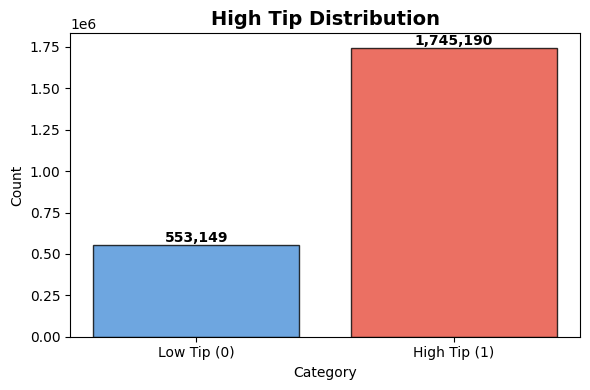

In [70]:
import matplotlib.pyplot as plt

# 1. Prepare the data using group_by (compatible with all Polars versions)
counts_df = (
    taxi_df.group_by("high_tip")
    .agg(pl.len().alias("count"))
    .sort("high_tip")
)

# 2. Extract the values for plotting
categories = ["Low Tip (0)", "High Tip (1)"]
counts = counts_df["count"].to_list()

# 3. Create the plot
fig, ax = plt.subplots(figsize=(6, 4))

# We use ax.bar instead of the pandas-style .plot(kind='bar')
bars = ax.bar(categories, counts, color=['#4A90D9', '#E74C3C'], edgecolor='black', alpha=0.8)

# Formatting
ax.set_title('High Tip Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Count')

# 4. Add the text labels on top of the bars
for i, count in enumerate(counts):
    ax.text(i, count + (max(counts) * 0.01), f'{count:,}', 
            ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [71]:
import polars as pl

# 1. Grab numeric columns (Integers and Floats)
numeric_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype.is_numeric()
]

# 2. Grab categorical columns (Strings/Objects)
# Note: Polars uses 'String' instead of 'object'
categorical_features = [
    col for col, dtype in taxi_df.schema.items() 
    if dtype == pl.String
]

# 3. Remove your targets so you don't "leak" the answer to the model
if 'tip_amount' in numeric_features: numeric_features.remove('tip_amount')
if 'high_tip' in numeric_features: numeric_features.remove('high_tip')
if "PULocationID" in numeric_features: numeric_features.remove("PULocationID")
if "DOLocationID" in numeric_features: numeric_features.remove("DOLocationID")
if "total_amount" in numeric_features: numeric_features.remove("total_amount")
#if "fare_amount" in numeric_features: numeric_features.remove("fare_amount")
#if "tolls_amount" in numeric_features: numeric_features.remove("tolls_amount")
#if "mta_tax" in numeric_features: numeric_features.remove("mta_tax")
# (Remove 'income' or whatever your specific target name is here)

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")



Numeric features (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Categorical features (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']


In [72]:
import polars as pl

# 1. Replace '?' with None (Polars' NaN equivalent) across all string columns
# Then cast numeric-looking strings back to numbers if necessary
taxi_df = taxi_df.with_columns(
    pl.all().map_batches(lambda s: s.replace("?", None) if s.dtype == pl.String else s)
)

# 2. Calculate Missing Value Percentages
total_rows = len(taxi_df)
missing_stats = (
    taxi_df.select([
        (pl.col(c).is_null().sum() / total_rows * 100).round(2).alias(c)
        for c in taxi_df.columns
    ])
    .melt(variable_name="column", value_name="missing_pct")
    .filter(pl.col("missing_pct") > 0)
)


# 3. FIXED: Calculate rows with at least one null (Total affected)
# any_horizontal returns True if AT LEAST ONE column in that row is null
total_affected = taxi_df.filter(pl.any_horizontal(pl.all().is_null())).height

# 4. Define the columns you want to check for your cleaning step later
# (Used for your 'cols' variable in the cleaning summary)
cols = taxi_df.columns 

print("Missing value percentages:")
print(missing_stats)
print(f"\nTotal rows affected: {total_affected:,} ({(total_affected/total_rows*100):.1f}%)")

Missing value percentages:
shape: (0, 2)
┌────────┬─────────────┐
│ column ┆ missing_pct │
│ ---    ┆ ---         │
│ str    ┆ f64         │
╞════════╪═════════════╡
└────────┴─────────────┘

Total rows affected: 0 (0.0%)


/var/folders/yd/xx3gc_bd0y911x26fq021tgw0000gn/T/ipykernel_58383/3675321585.py:16: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="column", value_name="missing_pct")


In [73]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# 1. Numeric pipeline: Median handles outliers better than Mean (Stats Exam win!)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Categorical pipeline: Standard for handling strings
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print('Numeric transformer steps:', [step[0] for step in numeric_transformer.steps])
print('Categorical transformer steps:', [step[0] for step in categorical_transformer.steps])
from sklearn.compose import ColumnTransformer

# 3. Combine into a preprocessor
# We tell it: use numeric_transformer for numeric_features, 
# and categorical_transformer for categorical_features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drops any columns we didn't explicitly include (like targets)
)

print("Preprocessor successfully defined!")

Numeric transformer steps: ['imputer', 'scaler']
Categorical transformer steps: ['imputer', 'onehot']
Preprocessor successfully defined!


In [74]:
from sklearn.compose import ColumnTransformer

# Initialize the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print('ColumnTransformer configured:')
print(f'  Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'  Categorical features ({len(categorical_features)}): {categorical_features}')

ColumnTransformer configured:
  Numeric features (20): ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
  Categorical features (3): ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']


In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create full pipeline: preprocessing + model
# We use max_iter=1000 to ensure the solver has enough iterations to converge
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print('Full Pipeline:')
print(pipeline)

Full Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['VendorID',
                                                   'passenger_count',
                                                   'trip_distance',
                                                   'RatecodeID', 'payment_type',
                                                   'fare_amount', 'extra',
                                                   'mta_tax', 'tolls_amount',
                                                   'improvement_surcharge',
                                       

In [76]:
from sklearn.model_selection import train_test_split
import polars as pl
import numpy as np

# 1. Define Features and Target
# We use the corrected feature lists we discussed
X = taxi_df.select(numeric_features + categorical_features)
y = taxi_df.select("high_tip").to_series().to_numpy()

# 2. First Split: 70% Training, 30% Temporary (for Val/Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

# 3. Second Split: Divide the 30% temporary set exactly in half (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

# 4. Apply Preprocessing (Requirement b)
# CRITICAL: We fit_transform the training data, then ONLY transform val/test.
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# 5. Documentation Summary (Requirement c & d)
def get_dist(labels):
    counts = np.bincount(labels.astype(int))
    low = counts[0] if len(counts) > 0 else 0
    high = counts[1] if len(counts) > 1 else 0
    return f"{low:,} Low / {high:,} High ({(high/len(labels))*100:.2f}% High)"

print("--- Data Split & Stratification Summary ---")
print(f"{'Split Set':<15} | {'Row Count':<10} | {'Class Distribution (Target: high_tip)'}")
print("-" * 75)
print(f"{'Training':<15} | {len(y_train):<10,} | {get_dist(y_train)}")
print(f"{'Validation':<15} | {len(y_val):<10,} | {get_dist(y_val)}")
print(f"{'Testing':<15} | {len(y_test):<10,} | {get_dist(y_test)}")

print("\n--- Feature Transformation Summary ---")
print(f"Total Features Processed: {X_train_transformed.shape[1]}")
print(f"Numeric Features Scaled: {len(numeric_features)}")
print(f"Categorical Features Encoded: {len(categorical_features)}")

--- Data Split & Stratification Summary ---
Split Set       | Row Count  | Class Distribution (Target: high_tip)
---------------------------------------------------------------------------
Training        | 1,608,837  | 387,204 Low / 1,221,633 High (75.93% High)
Validation      | 344,751    | 82,972 Low / 261,779 High (75.93% High)
Testing         | 344,751    | 82,973 Low / 261,778 High (75.93% High)

--- Feature Transformation Summary ---
Total Features Processed: 38
Numeric Features Scaled: 20
Categorical Features Encoded: 3


___

In [77]:
# 1. Identify the types after transformation
# (StandardScaler keeps numeric count; One-Hot expands categorical)
all_input_cols = set(taxi_df.columns)
modeled_cols = set(numeric_features + categorical_features)
excluded_cols = all_input_cols - modeled_cols - {'high_tip'}

print("===============================================================")
print("                  FEATURE MODELING SUMMARY                     ")
print("===============================================================")

print(f"\n[NUMERIC FEATURES] - Total: {len(numeric_features)}")
print(f"Columns: {numeric_features}")
print("Processing: Median Imputation + Standardization (Z-score scaling)")

print(f"\n[CATEGORICAL FEATURES] - Total: {len(categorical_features)}")
print(f"Columns: {categorical_features}")
print("Processing: Most Frequent Imputation + One-Hot Encoding")

print(f"\n[EXCLUDED FEATURES] - Total: {len(excluded_cols)}")
print("-" * 30)

for col in sorted(excluded_cols):
    reason = ""
    if col in ['total_amount', 'fare_amount', 'tip_amount']:
        reason = "Target Leakage: Directly contains or calculates the dependent variable."
    elif 'datetime' in col:
        reason = "Non-numeric: Raw timestamps cannot be used in Logistic Regression without extraction."
    elif col in ['PULocationID', 'DOLocationID']:
        reason = "Redundancy: Replaced by higher-level 'Borough' features to reduce dimensionality."
    else:
        reason = "High Cardinality or Uninformative for this specific model."
    
    print(f"• {col:<22} | {reason}")

print("===============================================================")

                  FEATURE MODELING SUMMARY                     

[NUMERIC FEATURES] - Total: 20
Columns: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Processing: Median Imputation + Standardization (Z-score scaling)

[CATEGORICAL FEATURES] - Total: 3
Columns: ['store_and_fwd_flag', 'PU_Borough', 'DO_Borough']
Processing: Most Frequent Imputation + One-Hot Encoding

[EXCLUDED FEATURES] - Total: 6
------------------------------
• DOLocationID           | Redundancy: Replaced by higher-level 'Borough' features to reduce dimensionality.
• PULocationID           | Redundancy: Replaced by higher-level 'Borough' features to reduce dimensionality.
• tip_amount             | Target Leakage: Directly 

In [79]:
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. PREPARE THE DATA (UNIFIED SPLIT)
# We split X and y together using the same random_state to keep them aligned
# 'X' should be your feature set (excluding tip_amount, total_amount, etc.)
y_reg = taxi_df.select("tip_amount").to_series().to_numpy()

X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(
    X, y_reg, 
    test_size=0.30, 
    random_state=42
)

X_val, X_test, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_reg, 
    test_size=0.50, 
    random_state=42
)

# 2. DEFINE THE MODELS
lr_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

rf_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# 3. TRAIN WITH TIMERS
print("Training Baseline Models...")
start_lr = time.time()
lr_reg.fit(X_train, y_train_reg)
lr_time = time.time() - start_lr

start_rf = time.time()
rf_reg.fit(X_train, y_train_reg)
rf_time = time.time() - start_rf

# 4. EVALUATION FUNCTION
def get_regression_metrics(model, X, y_true, name, duration):
    preds = model.predict(X)
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)
    return {
        "Model": name,
        "MAE": f"{mae:.4f}",
        "RMSE": f"{rmse:.4f}",
        "R^2": f"{r2:.4f}",
        "Time (s)": f"{duration:.2f}s"
    }

# 5. GENERATE THE RESULTS TABLE
lr_stats = get_regression_metrics(lr_reg, X_val, y_val_reg, "Linear Regression", lr_time)
rf_stats = get_regression_metrics(rf_reg, X_val, y_val_reg, "Random Forest", rf_time)

results_df = pd.DataFrame([lr_stats, rf_stats])
print("\n--- Final Baseline Regression Performance ---")
print(results_df.to_string(index=False))

Training Baseline Models...

--- Final Baseline Regression Performance ---
            Model    MAE   RMSE    R^2 Time (s)
Linear Regression 1.2066 2.3311 0.6308    5.88s
    Random Forest 1.1834 2.3051 0.6390  210.59s


____


In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. PREPARE THE BINARY TARGET
y_clf = taxi_df.select("high_tip").to_series().to_numpy()

# Split X and y_clf together
X_train, X_temp, y_train_clf, y_temp_clf = train_test_split(
    X, y_clf, test_size=0.30, random_state=42
)
X_val, X_test, y_val_clf, y_test_clf = train_test_split(
    X_temp, y_temp_clf, test_size=0.50, random_state=42
)

# 2. DEFINE CLASSIFICATION PIPELINES
log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

rf_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

# 3. TRAIN
print("Training Classification Models...")
log_reg.fit(X_train, y_train_clf)
rf_clf.fit(X_train, y_train_clf)

# 4. EVALUATION FUNCTION
def get_classification_metrics(model, X, y_true, name):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1] # Needed for AUC-ROC
    
    return {
        "Model": name,
        "Accuracy": f"{accuracy_score(y_true, preds):.4f}",
        "Precision": f"{precision_score(y_true, preds):.4f}",
        "Recall": f"{recall_score(y_true, preds):.4f}",
        "F1-Score": f"{f1_score(y_true, preds):.4f}",
        "AUC-ROC": f"{roc_auc_score(y_true, probs):.4f}"
    }

# 5. RESULTS TABLE
log_stats = get_classification_metrics(log_reg, X_val, y_val_clf, "Logistic Regression")
rf_stats = get_classification_metrics(rf_clf, X_val, y_val_clf, "Random Forest Classifier")

results_clf_df = pd.DataFrame([log_stats, rf_stats])
print("\n--- Baseline Classification: Validation Set Performance ---")
print(results_clf_df.to_string(index=False))

Training Classification Models...

--- Baseline Classification: Validation Set Performance ---
                   Model Accuracy Precision Recall F1-Score AUC-ROC
     Logistic Regression   0.7719    0.7700 0.9979   0.8693  0.6090
Random Forest Classifier   0.7722    0.7697 0.9994   0.8696  0.6189
